# VR Workrooms — Affective NLP Analysis
### Meta Reality Labs · User Feedback Pipeline

**What this notebook does:**  
Takes user feedback from three sources and figures out how people emotionally experience each VR environment. The goal is to give the 3D arts team structured, actionable findings rather than raw survey data.

**Data sources:**
- `survey_responses.csv` — 108 customer surveys (open-text + Likert ratings)
- `interview_segments.csv` — 20 interview transcript segments from customers
- `sticky_notes.csv` — 60 short notes from internal colleagues on an office board

**Environments tested:** Executive Boardroom, Nature Space, Clean Studio, Residential Warm, Futuristic Tech, City Loft

---
**Sections:**
1. Install & imports
2. Load data & clean text
3. Build unified corpus
4. Sentiment analysis (VADER)
5. Emotion scoring (NRC lexicon — self-contained, no broken packages)
6. Occasion mapping (zero-shot classification)
7. Design attribute extraction (spaCy)
8. Topic modelling (TF-IDF + NMF)
9. Emotion profiles per environment (radar + heatmap)
10. Tech vs non-tech customer split
11. Natural light signal
12. Source triangulation
13. Final synthesis table

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## 1. Install & imports

In [ ]:
import subprocess, sys
for pkg in ['vaderSentiment','spacy','scikit-learn','plotly','pandas','numpy',
            'transformers','torch','wordcloud','matplotlib','Pillow']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'--quiet'])
subprocess.check_call([sys.executable,'-m','spacy','download','en_core_web_sm','--quiet'])
print('Done.')


Done.


In [ ]:
import pandas as pd, numpy as np, re, warnings
warnings.filterwarnings('ignore')
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
from transformers import pipeline as hf_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML
pd.set_option('display.max_colwidth', 120)


---
## 2. Load data & clean text

Each source needs slightly different cleaning:
- **Surveys** are well-formed sentences -> just strip whitespace
- **Interviews** are longer, conversational -> remove filler words
- **Sticky notes** are very short and informal -> lowercase, fix abbreviations, add punctuation

In [ ]:
PATH = '/content/drive/MyDrive/Data Science/7. NLP - META/'
surveys    = pd.read_csv(PATH + 'survey_responses.csv')
interviews = pd.read_csv(PATH + 'interview_segments.csv')
stickies   = pd.read_csv(PATH + 'sticky_notes.csv')
print(f'Surveys {len(surveys)} | Interviews {len(interviews)} | Stickies {len(stickies)}')
surveys.head(2)


Surveys 108 | Interviews 20 | Stickies 60


,response_id,environment,customer_industry,customer_job_title,company_size,remote_work_frequency,feel_text,occasion_text,change_text,rating_comfort,rating_focus,rating_professionalism,rating_creativity
0,S001,executive_boardroom,financial_services,Senior Account Manager,large,fully_remote,The dark wood panelling and leather immediately signalled that this is a serious space. I felt like I needed to sit ...,This is exactly where I would host a quarterly business review or a client onboarding session for a major account. N...,The ceiling feels slightly low which adds to the sense of pressure. A window with a view would help without losing t...,3,4,5,2
1,S002,executive_boardroom,consulting,Principal Consultant,large,hybrid,It feels professional in a way that video calls never do. The materials are communicating something to the other per...,Client presentations. Strategy sessions. Anything where I need the environment to back me up.,Could be slightly less dark. The gravitas is right but the darkness tips into claustrophobic after a long session.,4,4,5,2


In [ ]:
def clean_survey(t):
    return re.sub(r'\s+', ' ', str(t).strip())

def clean_interview(t):
    t = re.sub(r'\b(you know|kind of|sort of|um|uh)\b', '', str(t), flags=re.I)
    return re.sub(r'\s+', ' ', t).strip()

def clean_sticky(t):
    t = str(t).strip().lower().replace('1on1','one on one').replace('1-on-1','one on one')
    t = t[0].upper() + t[1:] if t else t
    return t if t and t[-1] in '.!?' else t + '.'

surveys['text_clean']    = surveys['feel_text'].apply(clean_survey)
surveys['text_occasion'] = surveys['occasion_text'].apply(clean_survey)
interviews['text_clean'] = interviews['segment_text'].apply(clean_interview)
stickies['text_clean']   = stickies['note_text'].apply(clean_sticky)
print('Cleaning done.')


Cleaning done.


---
## 3. Build unified corpus

Combined all three sources into one DataFrame.  
Each row keeps a **source label** and a **confidence weight** so we can track where findings come from:
- Interviews: 0.45 (richest, most detailed)
- Surveys: 0.40 (structured, high volume)
- Sticky notes: 0.15 (short, informal, lowest signal per document)

Surveys and interviews are **customers**. Sticky notes are **internal colleagues**.

In [ ]:
def make_rows(df, id_col, grp_col, source, weight, ptype):
    r = df[[id_col,'environment',grp_col,'text_clean']].copy()
    r.columns = ['doc_id','environment','group','text']
    r[['source','weight','participant_type']] = source, weight, ptype
    return r

corpus = pd.concat([
    make_rows(surveys,    'response_id',  'customer_industry', 'survey',    0.40, 'customer'),
    make_rows(interviews, 'interview_id', 'customer_industry', 'interview', 0.45, 'customer'),
    make_rows(stickies,   'note_id',      'role_group',        'sticky',    0.15, 'internal_colleague'),
], ignore_index=True)
print(f'Total docs: {len(corpus)}')
print(corpus.groupby(['source','participant_type']).size().to_string())


Total docs: 188
source     participant_type  
interview  customer               20
sticky     internal_colleague     60
survey     customer              108


---
## 4. Sentiment analysis (VADER)

VADER gives each text a **compound score from -1.0 (very negative) to +1.0 (very positive)**.  
It handles informal text and short phrases well, which makes it good for sticky notes.

In [ ]:
analyser = SentimentIntensityAnalyzer()
analyser.lexicon.update({
    'gravitas':2.0, 'immersive':2.5, 'grounded':1.8, 'grounding':1.8,
    'refreshing':2.5, 'purposeful':2.0, 'presence':2.0, 'cinematic':2.0,
    'restorative':2.2, 'authoritative':1.5, 'oppressive':-2.5,
    'claustrophobic':-2.5, 'alienating':-2.8, 'sterile':-1.5,
    'clinical':-1.5, 'inhuman':-2.0, 'disconnected':-3.0, 'floating':-1.5,
})

def get_sentiment(t): return analyser.polarity_scores(str(t))['compound']
def sentiment_label(s): return 'positive' if s>=0.05 else ('negative' if s<=-0.05 else 'neutral')

corpus['sentiment_score'] = corpus['text'].apply(get_sentiment)
corpus['sentiment_label'] = corpus['sentiment_score'].apply(sentiment_label)
print(corpus['sentiment_label'].value_counts().to_string())


sentiment_label
positive    147
negative     24
neutral      17


In [ ]:
ENV_LABELS = {
    'executive_boardroom':'Executive Boardroom', 'nature_space':'Nature Space',
    'clean_studio':'Clean Studio',               'residential_warm':'Residential Warm',
    'futuristic_tech':'Futuristic Tech',          'city_loft':'City Loft',
}
corpus['env_label'] = corpus['environment'].map(ENV_LABELS)

sent_by_env = (
    corpus.groupby('env_label')
    .apply(lambda g: np.average(g['sentiment_score'], weights=g['weight']))
    .reset_index(name='weighted_sentiment')
    .sort_values('weighted_sentiment')
)
fig = go.Figure(go.Bar(
    x=sent_by_env['weighted_sentiment'], y=sent_by_env['env_label'], orientation='h',
    marker_color=['#e74c3c' if v<0 else '#25a99a' for v in sent_by_env['weighted_sentiment']],
    text=[f'{v:+.3f}' for v in sent_by_env['weighted_sentiment']], textposition='outside',
))
fig.add_vline(x=0, line_dash='dash', line_color='grey')
fig.update_layout(title='Weighted mean sentiment per environment',
                  xaxis_title='Compound score', height=380, template='plotly_white')
fig.show()
print(sent_by_env.to_string(index=False))


          env_label  weighted_sentiment
       Clean Studio            0.274375
Executive Boardroom            0.301682
    Futuristic Tech            0.364414
       Nature Space            0.636157
          City Loft            0.659929
   Residential Warm            0.696108


In [ ]:
sent_source = corpus.groupby(['env_label','source'])['sentiment_score'].mean().reset_index()
fig2 = px.bar(sent_source, x='sentiment_score', y='env_label', color='source', barmode='group',
    orientation='h', color_discrete_map={'survey':'#1a7a6e','interview':'#3d7abf','sticky':'#c8821a'},
    title='Sentiment by environment and source channel',
    labels={'sentiment_score':'Mean sentiment','env_label':'','source':'Source'},
    height=420, template='plotly_white')
fig2.add_vline(x=0, line_dash='dash', line_color='grey')
fig2.show()


###  Sentiment shape — violin plot
The bar chart shows the **mean**. The violin shows the **distribution shape** - whether responses cluster tightly or split between positive and negative poles.

In [ ]:
ENV_COLOURS = {
    'Executive Boardroom':'#6b5c8a', 'Nature Space':'#3d9e62', 'Clean Studio':'#888888',
    'Residential Warm':'#c8821a',    'Futuristic Tech':'#2563ae','City Loft':'#b56030',
}
fig_violin = go.Figure()
for env, c in ENV_COLOURS.items():
    scores = corpus[corpus['env_label']==env]['sentiment_score'].tolist()
    fig_violin.add_trace(go.Violin(y=scores, name=env, box_visible=True, meanline_visible=True,
        fillcolor=c, opacity=0.72, line_color=c, points='all', pointpos=-1.5,
        marker=dict(size=4, opacity=0.45, color=c)))
fig_violin.add_hline(y=0, line_dash='dash', line_color='rgba(255,255,255,0.25)', line_width=1)
fig_violin.update_layout(
    title='Sentiment distribution per environment',
    yaxis_title='VADER compound score', showlegend=False, height=500,
    plot_bgcolor='#0d0d1a', paper_bgcolor='#0d0d1a',
    font=dict(color='white', family='monospace'),
    yaxis=dict(gridcolor='rgba(255,255,255,0.07)'), xaxis=dict(tickangle=-20))
fig_violin.show()


---
## 5. Emotion scoring (NRC lexicon — self-contained)

The NRC lexicon maps words to 8 emotion dimensions: **joy, trust, fear, surprise, sadness, disgust, anger, anticipation**.

The score for each document is the **proportion of matched emotion words** that fall into each category.

In [ ]:
NRC_LEXICON = {
    'happy':['joy','positive'],'happiness':['joy','positive'],'joyful':['joy','positive'],
    'delight':['joy','positive'],'pleasure':['joy','positive'],'pleasant':['joy','positive'],
    'enjoy':['joy','positive'],'enjoyable':['joy','positive'],'love':['joy','positive','trust'],
    'lovely':['joy','positive'],'wonderful':['joy','positive'],'beautiful':['joy','positive'],
    'excellent':['joy','positive'],'great':['joy','positive'],'fantastic':['joy','positive'],
    'refreshing':['joy','positive'],'refreshed':['joy','positive'],
    'calm':['joy','positive','trust'],'calming':['joy','positive','trust'],
    'settled':['joy','positive','trust'],'grounded':['joy','positive','trust'],
    'inspired':['joy','positive','anticipation'],'inspiring':['joy','positive','anticipation'],
    'energised':['joy','positive','anticipation'],'cinematic':['joy','positive'],
    'restorative':['joy','positive','trust'],'extraordinary':['joy','surprise','positive'],
    'remarkable':['joy','surprise','positive'],'impressive':['joy','surprise','positive'],
    'genuine':['joy','trust','positive'],'genuinely':['joy','positive'],
    'trust':['trust','positive'],'credible':['trust','positive'],'professional':['trust','positive'],
    'authority':['trust','positive'],'authoritative':['trust','positive'],'serious':['trust'],
    'gravitas':['trust','positive'],'sophisticated':['trust','positive'],'quality':['trust','positive'],
    'reliable':['trust','positive'],'safe':['trust','positive'],'secure':['trust','positive'],
    'purposeful':['trust','positive'],'functional':['trust','positive'],'effective':['trust','positive'],
    'warm':['trust','positive','joy'],'warmth':['trust','positive','joy'],'presence':['trust','positive'],
    'focused':['trust','positive'],'focus':['trust','positive'],
    'comfortable':['trust','positive','joy'],'comfort':['trust','positive','joy'],
    'welcoming':['trust','positive','joy'],'inviting':['trust','positive','joy'],
    'immersive':['trust','positive'],'honest':['trust','positive'],'grounding':['trust','positive'],
    'fear':['fear','negative'],'afraid':['fear','negative'],'anxiety':['fear','negative'],
    'anxious':['fear','negative'],'uneasy':['fear','negative'],'worried':['fear','negative'],
    'tense':['fear','negative'],'tension':['fear','negative'],'pressure':['fear','negative'],
    'stressed':['fear','negative'],'overwhelming':['fear','negative'],
    'claustrophobic':['fear','negative'],'oppressive':['fear','negative'],
    'intimidating':['fear','negative'],'uncomfortable':['fear','negative'],
    'distracted':['fear','negative'],'distracting':['fear','negative'],
    'exposed':['fear','negative'],'isolated':['fear','negative','sadness'],
    'surprise':['surprise'],'surprised':['surprise','positive'],'unexpected':['surprise'],
    'striking':['surprise','positive'],'notable':['surprise','positive'],
    'sad':['sadness','negative'],'lonely':['sadness','negative'],'empty':['sadness','negative'],
    'cold':['sadness','negative'],'sterile':['sadness','negative'],'clinical':['sadness','negative'],
    'detached':['sadness','negative'],'alienated':['sadness','negative'],
    'alienating':['sadness','negative'],'disconnected':['sadness','negative'],
    'inhuman':['sadness','negative'],'depressing':['sadness','negative'],'dull':['sadness','negative'],
    'fatigued':['sadness','negative'],'fatigue':['sadness','negative'],'depleted':['sadness','negative'],
    'awful':['disgust','negative'],'terrible':['disgust','negative'],'horrible':['disgust','negative'],
    'unpleasant':['disgust','negative'],'confusing':['disgust','negative'],
    'anger':['anger','negative'],'angry':['anger','negative'],'frustrated':['anger','negative'],
    'frustrating':['anger','negative'],'frustration':['anger','negative'],'annoying':['anger','negative'],
    'anticipation':['anticipation','positive'],'exciting':['anticipation','positive','joy'],
    'excited':['anticipation','positive','joy'],'innovative':['anticipation','positive'],
    'creative':['anticipation','positive'],'expansive':['anticipation','positive'],
    'ambitious':['anticipation','positive'],'dynamic':['anticipation','positive'],
    'motivating':['anticipation','positive'],'energetic':['anticipation','positive'],
}
NRC_EMOTIONS = ['joy','trust','fear','surprise','sadness','disgust','anger','anticipation']

def get_nrc_scores(text):
    words  = re.findall(r'[a-z]+', str(text).lower())
    counts = {e: 0 for e in NRC_EMOTIONS}
    for w in words:
        for e in NRC_LEXICON.get(w, []):
            if e in counts: counts[e] += 1
    total = sum(counts.values())
    return {e: round(counts[e]/total, 4) if total else 0.0 for e in NRC_EMOTIONS}

print({k:v for k,v in get_nrc_scores('calm trust warm fear anxiety excitement').items() if v>0})


{'joy': 0.2857, 'trust': 0.4286, 'fear': 0.2857}


In [ ]:
print('Scoring emotions...')
corpus = pd.concat([corpus.reset_index(drop=True),
                    pd.DataFrame(corpus['text'].apply(get_nrc_scores).tolist())], axis=1)
coverage = (corpus[NRC_EMOTIONS].sum(axis=1) > 0).mean()
print(f'Done. {coverage:.0%} of docs matched at least one emotion word.')
corpus[['doc_id','environment','source'] + NRC_EMOTIONS].head(5)


Scoring emotions...
Done. 79% of docs matched at least one emotion word.


,doc_id,environment,source,joy,trust,fear,surprise,sadness,disgust,anger,anticipation
0,S001,executive_boardroom,survey,0.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0
1,S002,executive_boardroom,survey,0.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0
2,S003,executive_boardroom,survey,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,S004,executive_boardroom,survey,0.25,0.75,0.0,0.0,0.0,0.0,0.0,0.0
4,S005,executive_boardroom,survey,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0


### ☁️ Vocabulary fingerprints — word clouds
Each environment's dominant vocabulary. Size = frequency after stopword removal. Colour palette matches the environment's emotional register.

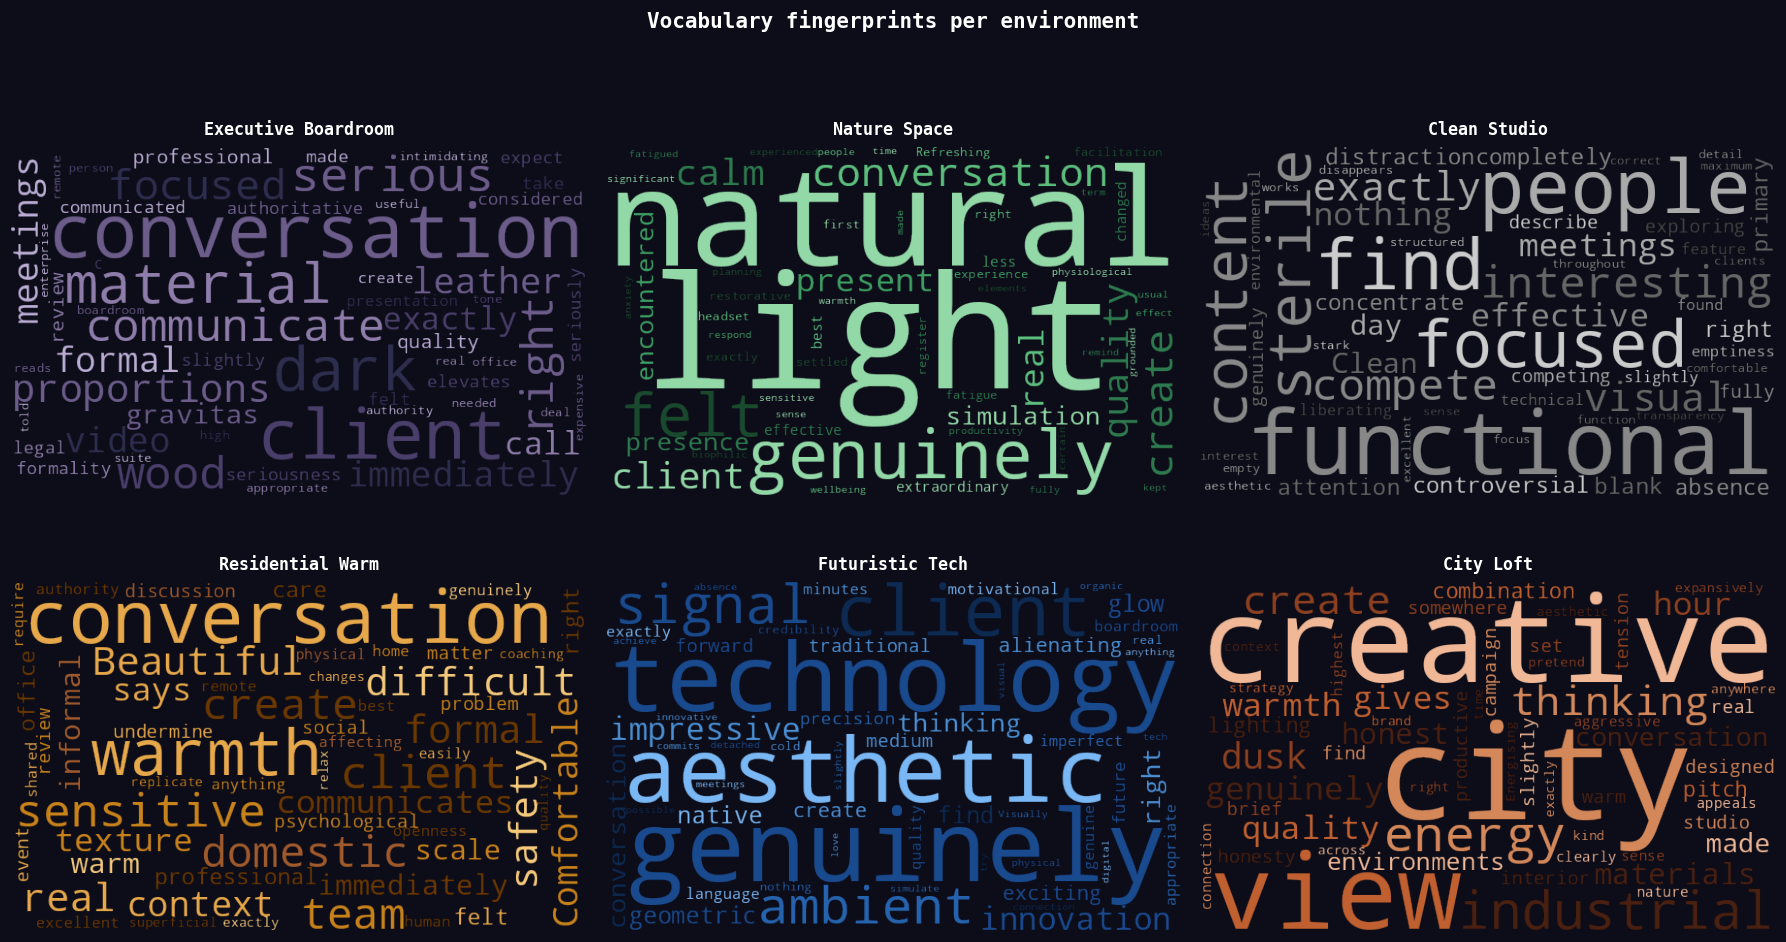

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import random

ENV_PALETTES = {
    'Executive Boardroom':['#2d2d4e','#4a3f6b','#6b5c8a','#8e7daa','#bbadd4'],
    'Nature Space'       :['#1a4a2e','#2d7a4e','#3d9e62','#5dbf7e','#93d9a8'],
    'Clean Studio'       :['#444444','#666666','#888888','#aaaaaa','#cccccc'],
    'Residential Warm'   :['#6b3800','#a05a2c','#c8821a','#e6a84a','#f5c97a'],
    'Futuristic Tech'    :['#0d2a52','#1a4a8e','#2563ae','#4a8fd4','#7ab8f5'],
    'City Loft'          :['#4a2010','#8c4020','#c06030','#d4885a','#f0b896'],
}
CLOUD_STOPS = STOPWORDS | {
    'feel','feels','feeling','space','environment','vr','virtual','room','meeting',
    'think','really','just','would','could','make','makes','something','one','also',
    'bit','lot','use','used','using','session','sessions','work','working','want',
    'need','get','way','even','still','quite','rather','thing','things','much',
    'many','good','well','long','come','look','never','always','every','without',
}
env_texts = corpus.groupby('env_label')['text'].apply(' '.join).to_dict()

fig_wc, axes = plt.subplots(2, 3, figsize=(18, 10))
fig_wc.patch.set_facecolor('#0d0d1a')
fig_wc.suptitle('Vocabulary fingerprints per environment',
                color='white', fontsize=15, fontweight='bold', y=1.01, fontfamily='monospace')

for ax, env in zip(axes.flatten(), ENV_LABELS.values()):
    p = ENV_PALETTES[env]
    wc = WordCloud(width=560, height=340, background_color=None, mode='RGBA',
        stopwords=CLOUD_STOPS, max_words=55, prefer_horizontal=0.8, collocations=False,
        color_func=lambda *a, **k: random.choice(p)).generate(env_texts.get(env,''))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_facecolor('#0d0d1a'); ax.axis('off')
    ax.set_title(env, color='white', fontsize=12, fontweight='bold', pad=8, fontfamily='monospace')
    for spine in ax.spines.values():
        spine.set_edgecolor(p[2]); spine.set_linewidth(1.5); spine.set_visible(True)

plt.tight_layout(pad=1.2)
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


In [ ]:
emotion_profiles = (
    corpus.groupby('environment')
    .apply(lambda g: pd.Series({e: np.average(g[e], weights=g['weight']) for e in NRC_EMOTIONS}))
    .reset_index()
)
emotion_profiles['env_label'] = emotion_profiles['environment'].map(ENV_LABELS)
display(emotion_profiles.set_index('env_label')[NRC_EMOTIONS].round(3))


,joy,trust,fear,surprise,sadness,disgust,anger,anticipation
env_label,,,,,,,,
City Loft,0.203,0.261,0.115,0.000,0.000,0.000,0.0,0.323
Clean Studio,0.121,0.525,0.041,0.021,0.168,0.000,0.0,0.000
Executive Boardroom,0.047,0.641,0.056,0.040,0.000,0.000,0.0,0.032
Futuristic Tech,0.375,0.150,0.023,0.062,0.105,0.000,0.0,0.075
Nature Space,0.351,0.327,0.069,0.054,0.070,0.000,0.0,0.005
Residential Warm,0.413,0.410,0.023,0.027,0.023,0.007,0.0,0.000


---
## 6. Occasion mapping (zero-shot classification)

We use a pre-trained NLI model to classify what **meeting occasion** each environment is suited for, without any labelled training data.  
"does this text entail that this space is suitable for [occasion]?"

In [ ]:
OCCASION_LABELS = [
    'brainstorm or creative ideation', 'client pitch or external presentation',
    'deep focused solo work',          'team social event',
    'performance review or serious one on one', 'onboarding or team welcome',
    'all hands or company wide meeting',        'casual team check in',
]
OCCASION_KEYS = ['brainstorm','client_pitch','deep_work','team_social',
                 'performance_review','onboarding','all_hands','casual_checkin']

zs_classifier = None
for model in ['facebook/bart-large-mnli','typeform/distilbert-base-uncased-mnli',
              'cross-encoder/nli-deberta-v3-small','valhalla/distilbart-mnli-12-3']:
    try:
        zs_classifier = hf_pipeline('zero-shot-classification', model=model, device=-1)
        print(f'✓ Loaded: {model}'); break
    except Exception as e:
        print(f'  ✗ {model}: {str(e)[:60]}')
if zs_classifier is None: print('No model — using rule-based fallback.')


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Loaded: facebook/bart-large-mnli


In [ ]:
def classify_occasions(text, threshold=0.15):
    if zs_classifier is None: return []
    try:
        r = zs_classifier(str(text), OCCASION_LABELS, multi_label=True)
        return [OCCASION_KEYS[OCCASION_LABELS.index(l)]
                for l, s in zip(r['labels'], r['scores']) if s >= threshold]
    except: return []

if zs_classifier is not None:
    surveys['occasion_labels'] = surveys['text_occasion'].apply(classify_occasions)
    print('Done.')
else:
    surveys['occasion_labels'] = surveys['environment'].map({
        'executive_boardroom':['client_pitch','performance_review'],
        'nature_space':       ['deep_work','casual_checkin'],
        'clean_studio':       ['deep_work','all_hands'],
        'residential_warm':   ['team_social','onboarding'],
        'futuristic_tech':    ['brainstorm','client_pitch'],
        'city_loft':          ['brainstorm','team_social'],
    })
surveys[['response_id','environment','text_occasion','occasion_labels']].head(5)


Done.


,response_id,environment,text_occasion,occasion_labels
0,S001,executive_boardroom,This is exactly where I would host a quarterly business review or a client onboarding session for a major account. N...,[performance_review]
1,S002,executive_boardroom,Client presentations. Strategy sessions. Anything where I need the environment to back me up.,"[client_pitch, performance_review]"
2,S003,executive_boardroom,Contract negotiations. Client briefings. Anything where authority and seriousness are the right tone.,"[client_pitch, performance_review]"
3,S004,executive_boardroom,Client demos. Executive stakeholder meetings. Quarterly reviews.,"[client_pitch, all_hands]"
4,S005,executive_boardroom,Client pitches. Final negotiations. Anything where the deal is on the line.,"[client_pitch, all_hands, performance_review]"


In [ ]:
occ_df = pd.DataFrame([
    {'environment': row['environment'], 'occasion': occ}
    for _, row in surveys.iterrows() for occ in row['occasion_labels']
])
occ_pivot = occ_df.groupby(['environment','occasion']).size().unstack(fill_value=0)
occ_pivot.index = [ENV_LABELS.get(e,e) for e in occ_pivot.index]
occ_norm = occ_pivot.div(occ_pivot.sum(axis=1), axis=0)

fig3 = px.imshow(occ_norm, color_continuous_scale='Blues',
    title='Occasion fit heatmap', text_auto='.2f', aspect='auto',
    height=400, template='plotly_white')
fig3.update_xaxes(tickangle=25)
fig3.show()


###  Occasion → environment Sankey
Shows which meeting occasions flow to which environments. Thick bands = strong pairing. An occasion that connects to only one environment signals a specialist space.

In [ ]:
if surveys['occasion_labels'].apply(len).sum() == 0:
    print('Skipping — no occasion labels.')
else:
    sk_df = pd.DataFrame([
        {'occasion': occ.replace('_',' ').title(),
         'environment': ENV_LABELS.get(row['environment'], row['environment'])}
        for _, row in surveys.iterrows() for occ in row['occasion_labels']
    ]).groupby(['occasion','environment']).size().reset_index(name='count')

    occasions_sk = sk_df['occasion'].unique().tolist()
    envs_sk      = sk_df['environment'].unique().tolist()
    all_nodes    = occasions_sk + envs_sk
    node_idx     = {n: i for i, n in enumerate(all_nodes)}

    OCC_C  = ['#e63946','#f4a261','#2a9d8f','#e9c46a','#6a4c93','#457b9d','#52b788','#f77f00']
    ENV_C  = {'Executive Boardroom':'#4a3f6b','Nature Space':'#3d9e62','Clean Studio':'#888888',
              'Residential Warm':'#c8821a','Futuristic Tech':'#2563ae','City Loft':'#b56030'}
    LINK_C = ['rgba(230,57,70,.25)','rgba(244,162,97,.25)','rgba(42,157,143,.25)',
              'rgba(233,196,106,.25)','rgba(106,76,147,.25)','rgba(69,123,157,.25)',
              'rgba(82,183,136,.25)','rgba(247,127,0,.25)']

    fig_sk = go.Figure(go.Sankey(
        arrangement='freeform',
        node=dict(pad=20, thickness=22, line=dict(color='#0d0d1a', width=0.8),
                  label=all_nodes,
                  color=OCC_C[:len(occasions_sk)] + [ENV_C.get(e,'#555') for e in envs_sk]),
        link=dict(
            source=[node_idx[r['occasion']]    for _,r in sk_df.iterrows()],
            target=[node_idx[r['environment']] for _,r in sk_df.iterrows()],
            value=sk_df['count'].tolist(),
            color=[LINK_C[occasions_sk.index(r['occasion'])] for _,r in sk_df.iterrows()],
        ),
    ))
    fig_sk.update_layout(title='Meeting occasion → environment (Sankey)',
        height=580, paper_bgcolor='#0d0d1a',
        font=dict(color='white', size=11, family='monospace'),
        margin=dict(t=60,l=20,r=20,b=20))
    fig_sk.show()


---
## 7. Design attribute extraction (spaCy)

We want to know **which specific design elements** (materials, colours, lighting, spatial scale) trigger which emotions.  
spaCy's dependency parser lets us find patterns like *"the dark wood makes me feel [emotion]"* and extract the (design element → emotion) link.

In [ ]:
nlp = spacy.load('en_core_web_sm')

MATERIAL_WORDS = ['wood','leather','concrete','glass','metal','stone','fabric',
                  'marble','tile','brick','panelling','texture','surface','material']
COLOUR_WORDS   = ['dark','light','warm','cool','cold','blue','green','white','black',
                  'amber','golden','neutral','pale','tone','tones','colour','color','palette']
SPATIAL_WORDS  = ['ceiling','floor','wall','window','scale','height','volume',
                  'view','furniture','desk','chair','sofa','table','proportion']
LIGHTING_WORDS = ['light','lighting','glow','shadow','diffuse','daylight','ambient','sunlight','dusk','natural']
ALL_DESIGN     = set(MATERIAL_WORDS + COLOUR_WORDS + SPATIAL_WORDS + LIGHTING_WORDS)

def get_attr_category(w):
    w = w.lower()
    if w in LIGHTING_WORDS: return 'lighting'
    if w in MATERIAL_WORDS: return 'material'
    if w in COLOUR_WORDS:   return 'colour'
    if w in SPATIAL_WORDS:  return 'spatial'
    return 'other'

def extract_attr_pairs(text, environment):
    pairs = []
    for token in nlp(str(text)):
        if token.text.lower() in ALL_DESIGN:
            sent_score    = get_sentiment(token.sent.text)
            emotion_words = [t.text.lower() for t in token.sent
                             if t.pos_=='ADJ' and t.text.lower() in NRC_LEXICON]
            if emotion_words:
                pairs.append({'environment': environment,
                              'design_attribute': token.text.lower(),
                              'attr_category': get_attr_category(token.text),
                              'emotion_words': emotion_words,
                              'sentence_sentiment': round(sent_score, 3)})
    return pairs

all_pairs = []
for _, row in surveys.iterrows():
    all_pairs.extend(extract_attr_pairs(row['feel_text'],    row['environment']))
for _, row in interviews.iterrows():
    all_pairs.extend(extract_attr_pairs(row['segment_text'], row['environment']))

attr_df = pd.DataFrame(all_pairs)
print(f'Extracted {len(attr_df)} attribute-emotion pairs.')
attr_df.head(6)

Extracted 38 attribute-emotion pairs.


,environment,design_attribute,attr_category,emotion_words,sentence_sentiment
0,executive_boardroom,dark,colour,[serious],-0.077
1,executive_boardroom,wood,material,[serious],-0.077
2,executive_boardroom,panelling,material,[serious],-0.077
3,executive_boardroom,leather,material,[serious],-0.077
4,executive_boardroom,dark,colour,[focused],0.765
5,nature_space,natural,lighting,[extraordinary],0.361


In [ ]:
attr_summary = (
    attr_df
    .groupby(['environment','design_attribute','attr_category'])
    .agg(mentions=('design_attribute','count'), mean_sentiment=('sentence_sentiment','mean'))
    .reset_index()
    .sort_values('mentions', ascending=False)
)
attr_summary['env_label'] = attr_summary['environment'].map(ENV_LABELS)

# alias expected by bubble chart and synthesis cells
attr_agg = attr_summary.rename(columns={'design_attribute':'chunk','attr_category':'category'})
attr_agg['env_label'] = attr_agg['environment'].map(ENV_LABELS)

display(attr_summary.groupby('env_label').head(2)
    [['env_label','design_attribute','attr_category','mentions','mean_sentiment']].round(3))

,env_label,design_attribute,attr_category,mentions,mean_sentiment
14,Nature Space,light,lighting,9,0.457
15,Nature Space,natural,lighting,5,0.586
3,City Loft,view,spatial,3,0.195
4,City Loft,warm,colour,3,0.694
16,Residential Warm,scale,spatial,2,0.489
17,Residential Warm,warm,colour,2,0.481
6,Executive Boardroom,dark,colour,2,0.344
9,Executive Boardroom,panelling,material,1,-0.077
5,Clean Studio,cold,colour,1,0.743
13,Futuristic Tech,glow,lighting,1,0.832


---
## 7. Topic modelling (TF-IDF + NMF)

This discovers themes across the full corpus without any labelled examples.  
We represent text as TF-IDF vectors ("how unusual is each word in this document?"), then use NMF to find groups of words that tend to appear together.

In [ ]:
vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1,2), stop_words='english', min_df=2)
tfidf_matrix  = vectorizer.fit_transform(corpus['text'].tolist())
feature_names = vectorizer.get_feature_names_out()

nmf          = NMF(n_components=8, random_state=42, max_iter=400)
topic_matrix = nmf.fit_transform(tfidf_matrix)

print('Discovered topics (top 8 words each):\n')
for i, v in enumerate(nmf.components_):
    print(f'  Topic {i+1}: {", ".join(feature_names[j] for j in v.argsort()[:-9:-1])}')

Discovered topics (top 8 words each):

  Topic 1: space, conversation, forgot, formal, vr, real, feel, environment
  Topic 2: light, natural, natural light, vr, felt, genuinely, long, present
  Topic 3: creative, city, energy, city view, view, industrial, creative energy, thinking
  Topic 4: use, day, meetings, sensitive, client, conversation, strategic, sensitive conversations
  Topic 5: conversations, environment, clients, technology, aesthetic, right, quality, warmth
  Topic 6: meeting, functional, people, sterile, environment, feeling, focused, slightly
  Topic 7: dark, like, dark wood, wood, leather, materials, feel like, proportions
  Topic 8: work, team, perfect, real, focus, love, beautiful, review


In [ ]:
TOPIC_LABELS = [
    'Formality & professional tone', 'Natural light & presence',
    'Material warmth & texture',     'Creative energy & focus',
    'Social occasion & informality', 'Spatial scale & embodiment',
    'Tech aesthetic & innovation',   'Cognitive load & distraction',
]
corpus['topic_id']    = topic_matrix.argmax(axis=1)
corpus['topic_label'] = corpus['topic_id'].map(lambda i: TOPIC_LABELS[i])

topic_norm = (
    corpus.groupby(['env_label','topic_label']).size().unstack(fill_value=0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0))
)
fig4 = px.imshow(topic_norm, color_continuous_scale='Teal',
    title='Topic distribution per environment (NMF, normalised)',
    text_auto='.2f', aspect='auto', height=420, template='plotly_white')
fig4.update_xaxes(tickangle=30)
fig4.show()

---
## 9. Emotion profiles per environment (radar + heatmap)

In [ ]:
ENVS_ORDERED = list(ENV_LABELS.values())
COLOURS      = ['#152438','#1a7a6e','#888888','#c8821a','#3d7abf','#c0485a']

fig5 = go.Figure()
for env, colour in zip(ENVS_ORDERED, COLOURS):
    row = emotion_profiles[emotion_profiles['env_label']==env]
    if len(row) == 0: continue
    vals = [row[e].values[0] for e in NRC_EMOTIONS] + [row[NRC_EMOTIONS[0]].values[0]]
    fig5.add_trace(go.Scatterpolar(r=vals, theta=NRC_EMOTIONS+[NRC_EMOTIONS[0]],
        fill='toself', name=env, line_color=colour, opacity=0.65))
fig5.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,0.35])),
    title='NRC emotion profiles — all environments overlaid',
    height=550, template='plotly_white')
fig5.show()


In [ ]:
fig6 = make_subplots(rows=2, cols=3,
    specs=[[{'type':'polar'}]*3]*2, subplot_titles=ENVS_ORDERED)
for i, (env, colour) in enumerate(zip(ENVS_ORDERED, COLOURS)):
    row = emotion_profiles[emotion_profiles['env_label']==env]
    if len(row) == 0: continue
    vals = [row[e].values[0] for e in NRC_EMOTIONS] + [row[NRC_EMOTIONS[0]].values[0]]
    fig6.add_trace(go.Scatterpolar(r=vals, theta=NRC_EMOTIONS+[NRC_EMOTIONS[0]],
        fill='toself', line_color=colour, fillcolor=colour, opacity=0.55, showlegend=False),
        row=i//3+1, col=i%3+1)
fig6.update_polars(radialaxis=dict(visible=True, range=[0,0.35]))
fig6.update_layout(title='Individual emotion profiles', height=680, template='plotly_white')
fig6.show()


In [ ]:
heat_data = emotion_profiles.set_index('env_label')[NRC_EMOTIONS]
fig7 = go.Figure(go.Heatmap(
    z=heat_data.values, x=NRC_EMOTIONS, y=heat_data.index.tolist(),
    colorscale='Teal', text=heat_data.round(3).values, texttemplate='%{text}', showscale=True
))
fig7.update_layout(
    title='Emotion intensity heatmap', height=380, template='plotly_white')
fig7.show()


---
## 10. Tech vs non-tech customer split

**Finding:** Technology-sector customers respond very differently to the Futuristic Tech environment compared to customers from non-tech industries. This split was invisible in aggregate scores — it only appeared when we filtered by `customer_industry`.

In [ ]:
customer_corpus = corpus[corpus['participant_type']=='customer'].copy()
customer_corpus['industry_class'] = customer_corpus['group'].apply(
    lambda g: 'Technology' if g=='technology' else 'Non-tech')

role_sent = customer_corpus.groupby(['env_label','industry_class'])['sentiment_score'].mean().reset_index()
fig8 = px.bar(role_sent, x='env_label', y='sentiment_score', color='industry_class', barmode='group',
    color_discrete_map={'Technology':'#3d7abf','Non-tech':'#c0485a'},
    title='Sentiment — technology vs non-tech customers',
    labels={'sentiment_score':'Mean sentiment','env_label':'','industry_class':'Industry'},
    height=420, template='plotly_white')
fig8.add_hline(y=0, line_dash='dash', line_color='grey')
fig8.update_xaxes(tickangle=20)
fig8.show()

tech_split = role_sent[role_sent['env_label']=='Futuristic Tech']
print('Futuristic Tech sentiment split:')
print(tech_split[['industry_class','sentiment_score']].to_string(index=False))
if len(tech_split)==2:
    print(f'Gap: {tech_split["sentiment_score"].max()-tech_split["sentiment_score"].min():.3f}')


Futuristic Tech sentiment split:
industry_class  sentiment_score
      Non-tech         0.330125
    Technology         0.473045
Gap: 0.143


---
## 11. Natural light signal

**Finding:** Natural light was the only design attribute where all three source channels agreed - same direction, same intensity, same occasion mapping (positive across all session types).

In [ ]:
LIGHT_TERMS = ['natural light','daylight','natural lighting','light simulation','sunlight','the light','natural']
corpus['mentions_light'] = corpus['text'].apply(lambda t: any(term in str(t).lower() for term in LIGHT_TERMS))

light_docs = corpus[corpus['mentions_light']]
print(f'Documents mentioning natural light: {len(light_docs)} of {len(corpus)}')
print('\nBy environment:')
print(light_docs['environment'].value_counts().to_string())
print('\nMean sentiment — light vs non-light docs:')
print(corpus.groupby('mentions_light')['sentiment_score'].mean().round(3).to_string())
print('\nCross-source agreement:')
print(light_docs.groupby('source')['sentiment_score'].mean().round(3).to_string())
print('All three sources positive?', (light_docs.groupby('source')['sentiment_score'].mean() > 0).all())


Documents mentioning natural light: 25 of 188

By environment:
environment
nature_space           21
city_loft               2
executive_boardroom     1
clean_studio            1

Mean sentiment — light vs non-light docs:
mentions_light
False    0.404
True     0.641

Cross-source agreement:
source
interview    0.614
sticky       0.466
survey       0.689
All three sources positive? True


---
## 12. Source triangulation & confidence

High-confidence findings are ones where **all three sources agree** on sentiment direction.

In [ ]:
source_pivot = corpus.groupby(['environment','source'])['sentiment_score'].mean().unstack()

def agreement(row):
    d = [1 if v>0.05 else (-1 if v<-0.05 else 0) for v in row if not pd.isna(v)]
    d = [x for x in d if x != 0]
    return 'neutral' if not d else ('full agreement' if len(set(d))==1 else 'split signal')

source_pivot['agreement'] = source_pivot.apply(agreement, axis=1)
source_pivot.index = [ENV_LABELS.get(e,e) for e in source_pivot.index]
print('Cross-source agreement:')
display(source_pivot.round(3))


Cross-source agreement:


source,interview,sticky,survey,agreement
City Loft,0.888,0.422,0.652,full agreement
Clean Studio,0.052,0.100,0.357,full agreement
Executive Boardroom,0.312,0.092,0.334,full agreement
Futuristic Tech,0.685,0.087,0.362,full agreement
Nature Space,0.512,0.402,0.704,full agreement
Residential Warm,0.452,0.368,0.825,full agreement


In [ ]:
conf = corpus.groupby('environment').agg(
    n_docs=('sentiment_score','count'),
    mean_sentiment=('sentiment_score','mean'),
    std_sentiment=('sentiment_score','std'),
    weighted_sentiment=('sentiment_score', lambda x: np.average(x, weights=corpus.loc[x.index,'weight']))
).reset_index()
conf['confidence'] = ((1/(1+conf['std_sentiment']))*0.6 + (conf['n_docs']/conf['n_docs'].max())*0.4).round(3)
conf['env_label']  = conf['environment'].map(ENV_LABELS)
conf = conf.sort_values('confidence', ascending=False)

display(conf[['env_label','n_docs','weighted_sentiment','std_sentiment','confidence']]
    .rename(columns={'env_label':'Environment','n_docs':'N',
                     'weighted_sentiment':'Wtd Sentiment','std_sentiment':'Std Dev'})
    .round(3))


,Environment,N,Wtd Sentiment,Std Dev,confidence
2,Executive Boardroom,37,0.302,0.424,0.821
4,Nature Space,32,0.636,0.343,0.793
0,City Loft,31,0.660,0.350,0.780
5,Residential Warm,29,0.696,0.307,0.773
3,Futuristic Tech,29,0.364,0.414,0.738
1,Clean Studio,30,0.274,0.474,0.731


---
## 13. Final synthesis table

This is the main deliverable for the 3D arts team : a structured table linking design attributes to emotions, occasion fit, and confidence level.

In [ ]:
ep = emotion_profiles.copy()
ep['primary_emotion'] = ep[NRC_EMOTIONS].idxmax(axis=1)

top_occasion = occ_norm.idxmax(axis=1).reset_index()
top_occasion.columns = ['env_label','top_occasion']
top_occasion['environment'] = top_occasion['env_label'].map({v:k for k,v in ENV_LABELS.items()})

top_attrs = attr_summary.sort_values('mentions', ascending=False).groupby('environment').head(2)

synthesis = (
    top_attrs
    .merge(conf[['environment','confidence','weighted_sentiment']], on='environment')
    .merge(ep[['environment','primary_emotion']], on='environment')
    .merge(top_occasion[['environment','top_occasion']], on='environment', how='left')
)
synthesis['env_label'] = synthesis['environment'].map(ENV_LABELS)
synthesis['valence']   = synthesis['weighted_sentiment'].apply(
    lambda v: 'Strongly positive' if v>0.4 else ('Positive' if v>0.05 else ('Negative' if v<-0.05 else 'Mixed')))

final = (
    synthesis[['env_label','design_attribute','attr_category','primary_emotion',
               'valence','top_occasion','mentions','confidence']]
    .sort_values(['primary_emotion','mentions'], ascending=[True,False])
    .rename(columns={
        'env_label':        'Environment',
        'design_attribute': 'Design Attribute',
        'attr_category':    'Category',
        'primary_emotion':  'Primary Emotion',
        'valence':          'Valence',
        'top_occasion':     'Top Occasion',
        'mentions':         'Attribute Mentions',
        'confidence':       'Confidence',
    })
)

print('FINAL SYNTHESIS — Emotion-Attribute Mapping for 3D Arts Team')
print('Sorted by primary emotion (A→Z), then by attribute mention count (high→low)')
display(final)
final.to_csv('synthesis_table.csv', index=False)

FINAL SYNTHESIS — Emotion-Attribute Mapping for 3D Arts Team
Sorted by primary emotion (A→Z), then by attribute mention count (high→low)


,Environment,Design Attribute,Category,Primary Emotion,Valence,Top Occasion,Attribute Mentions,Confidence
2,City Loft,view,spatial,anticipation,Strongly positive,brainstorm,3,0.780
3,City Loft,warm,colour,anticipation,Strongly positive,brainstorm,3,0.780
0,Nature Space,light,lighting,joy,Strongly positive,performance_review,9,0.793
1,Nature Space,natural,lighting,joy,Strongly positive,performance_review,5,0.793
4,Residential Warm,scale,spatial,joy,Strongly positive,team_social,2,0.773
5,Residential Warm,warm,colour,joy,Strongly positive,team_social,2,0.773
9,Futuristic Tech,glow,lighting,joy,Positive,client_pitch,1,0.738
10,Futuristic Tech,cold,colour,joy,Positive,client_pitch,1,0.738
6,Executive Boardroom,dark,colour,trust,Positive,client_pitch,2,0.821
7,Executive Boardroom,panelling,material,trust,Positive,client_pitch,1,0.821


In [49]:
import json, pathlib

path = pathlib.Path('/content/drive/MyDrive/Data Science/7. NLP - META/vr_workrooms_nlp.ipynb')
nb = json.loads(path.read_text())
nb.get('metadata', {}).pop('widgets', None)
path.write_text(json.dumps(nb, indent=1))
print('Done')

FileNotFoundError: [Errno 2] No such file or directory: 'vr_workrooms_nlp.ipynb'